# Modeling Malware Spread on Computer Networks Using Differential Equations
**Math 252: Section 1 Final Project**
**Author:** Zeal Shah

**Description:** This notebook simulates malware transmission using SIR and SIRS differential equation frameworks. It covers numerical integration using `scipy.integrate.odeint`, phase portraits, bifurcation analysis, and parameter sensitivity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Global aesthetic settings 
# Setting all text and axis colors to red to match visual requirements
plt.rcParams['text.color'] = 'red'
plt.rcParams['axes.labelcolor'] = 'red'
plt.rcParams['xtick.color'] = 'red'
plt.rcParams['ytick.color'] = 'red'
plt.rcParams['axes.edgecolor'] = 'red'

## 1. Defining the Differential Equations
Here we set up the system of ODEs that govern the change in device states over time for both the base SIR model (permanent patches) and the modified SIRS model (expiring patches).

In [2]:
def sir_model(y, t, beta, gamma):
    """Base model: Permanent recovery."""
    S, I, R = y
    dSdt = -beta * S * I
    dIdt = beta * S * I - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

def sirs_model(y, t, beta, gamma, mu):
    """Modified model: Patches expire at rate mu."""
    S, I, R = y
    dSdt = -beta * S * I + mu * R
    dIdt = beta * S * I - gamma * I
    dRdt = gamma * I - mu * R
    return [dSdt, dIdt, dRdt]

# Global initial conditions: 99% susceptible, 1% infected
y0 = [0.99, 0.01, 0.0]
t = np.linspace(0, 50, 500) # 50 days of simulation

## Visualization 1: Time-Series Graphs (S, I, R vs. Time)
Comparing the physical spread of the malware under three different $R_0$ regimes: decay, slow growth, and aggressive outbreak.

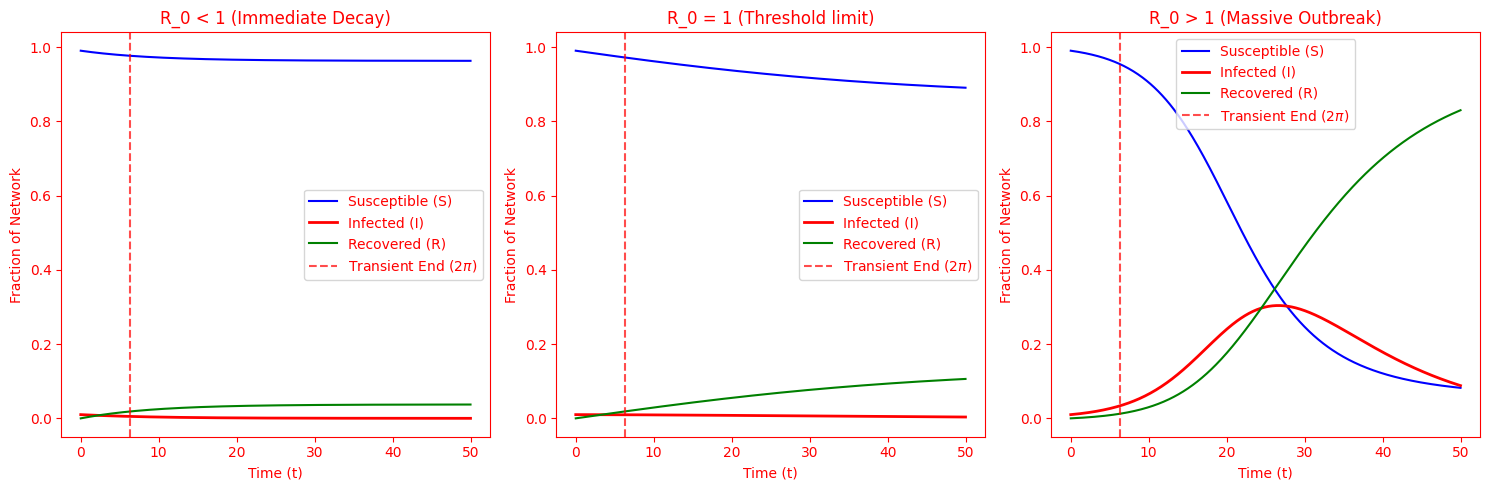

In [3]:
# --- VISUALIZATION 1: TIME SERIES ---
fig1, axes = plt.subplots(1, 3, figsize=(15, 5))

scenarios = [(0.3, 0.4), (0.3, 0.3), (0.3, 0.1)] 
titles = ['R_0 < 1 (Immediate Decay)', 'R_0 = 1 (Threshold limit)', 'R_0 > 1 (Massive Outbreak)']

for i, (beta, gamma) in enumerate(scenarios):
    sol = odeint(sir_model, y0, t, args=(beta, gamma))
    axes[i].plot(t, sol[:, 0], 'b-', label='Susceptible (S)')
    axes[i].plot(t, sol[:, 1], 'r-', linewidth=2, label='Infected (I)')
    axes[i].plot(t, sol[:, 2], 'g-', label='Recovered (R)')
    
    # Corrected with a raw string (r'') to fix the SyntaxWarning
    axes[i].axvline(2*np.pi, color='red', linestyle='--', alpha=0.7, label=r'Transient End ($2\pi$)')
    
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Time (t)')
    axes[i].set_ylabel('Fraction of Network')
    axes[i].legend()

plt.tight_layout()
plt.show()

## Visualization 2: Phase Portrait
Mapping the direction field in the S-I plane to show how varying initial infection sizes all flow toward the Disease-Free equilibrium on the horizontal axis.

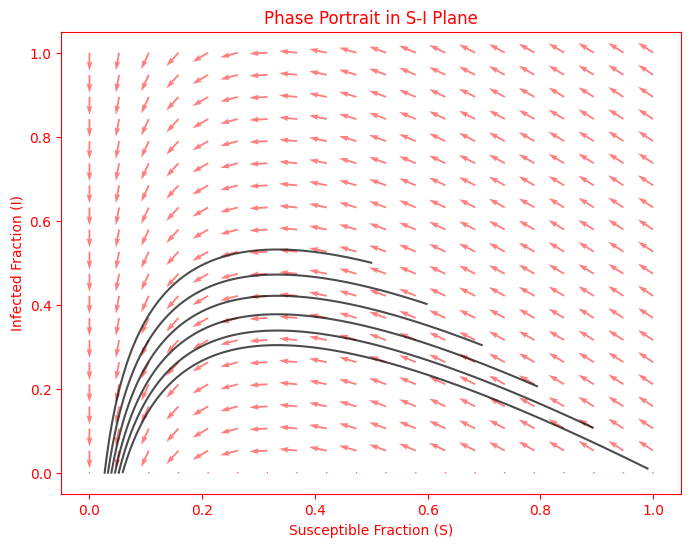

In [4]:
# --- VISUALIZATION 2: PHASE PORTRAIT ---
fig2, ax = plt.subplots(figsize=(8, 6))
beta, gamma = 0.3, 0.1

# Create a meshgrid for the vector field
S_grid, I_grid = np.meshgrid(np.linspace(0, 1, 20), np.linspace(0, 1, 20))
dS = -beta * S_grid * I_grid
dI = beta * S_grid * I_grid - gamma * I_grid

# Normalize the vectors for cleaner plotting
norm = np.hypot(dS, dI)
norm[norm == 0] = 1 
ax.quiver(S_grid, I_grid, dS/norm, dI/norm, color='red', alpha=0.5)

# Plot actual solution trajectories from different starting infection sizes
for I0 in np.linspace(0.01, 0.5, 6):
    sol = odeint(sir_model, [1-I0, I0, 0], np.linspace(0, 100, 1000), args=(beta, gamma))
    ax.plot(sol[:, 0], sol[:, 1], 'k-', alpha=0.7)

ax.set_xlabel('Susceptible Fraction (S)')
ax.set_ylabel('Infected Fraction (I)')
ax.set_title('Phase Portrait in S-I Plane')
plt.show()

## Visualization 3: Bifurcation Diagram
Sweeping the patching rate ($\gamma$) to find the exact transcritical bifurcation point where the malware stops sustaining an endemic infection.

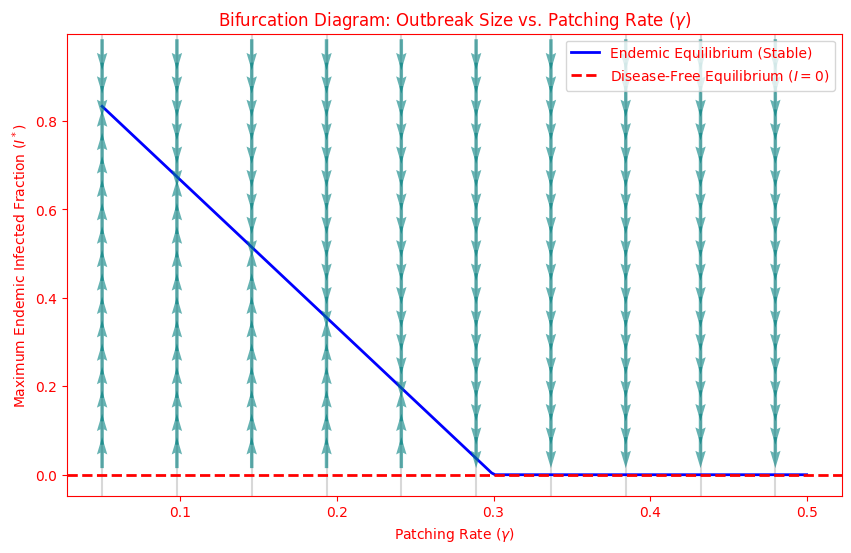

In [9]:
# --- VISUALIZATION 3: BIFURCATION DIAGRAM (DYNAMIC PHASE LINES) ---
fig3, ax = plt.subplots(figsize=(10, 6))

gamma_vals = np.linspace(0.05, 0.5, 200)
beta = 0.3

# The equilibrium curves
I_max = [max(0, 1 - g/beta) for g in gamma_vals]

ax.plot(gamma_vals, I_max, 'b-', linewidth=2, label='Endemic Equilibrium (Stable)')
ax.axhline(0, color='red', linewidth=2, linestyle='--', label=r'Disease-Free Equilibrium ($I=0$)')

# --- DYNAMIC VECTOR FIELD (No Hardcoding) ---
# 1. Define the grid points for our phase lines
phase_gammas = np.linspace(0.05, 0.48, 10) # The vertical line x-coordinates
I_points = np.linspace(0.05, 0.95, 18)     # The arrow y-coordinates
G_grid, I_grid = np.meshgrid(phase_gammas, I_points)

# 2. Calculate the actual derivative at every point
# Using the proportional logistic equation for the endemic state: dI/dt ~ I * ((1 - gamma/beta) - I)
dI = I_grid * ((1 - G_grid/beta) - I_grid)
dG = np.zeros_like(G_grid) # No left/right movement on phase lines

# 3. Normalize the arrows so they are uniform in length, preserving only the direction
norm = np.abs(dI)
norm[norm == 0] = 1 # Prevent division by zero directly on the equilibria
dI_direction = dI / norm

# 4. Draw the dynamic arrows and the vertical lines
ax.quiver(G_grid, I_grid, dG, dI_direction, color='teal', pivot='mid', scale=25, alpha=0.6, zorder=2)

for g in phase_gammas:
    ax.axvline(g, color='gray', linestyle='-', alpha=0.3, zorder=1)

# Formatting
ax.set_xlabel(r'Patching Rate ($\gamma$)')
ax.set_ylabel(r'Maximum Endemic Infected Fraction ($I^*$)')
ax.set_title(r'Bifurcation Diagram: Outbreak Size vs. Patching Rate ($\gamma$)')
ax.legend(loc='upper right')

plt.show()

## Visualization 4: Sensitivity Heat-map
Testing the sensitivity of the network to changes in BOTH the infection rate ($\beta$) and patching rate ($\gamma$) simultaneously.

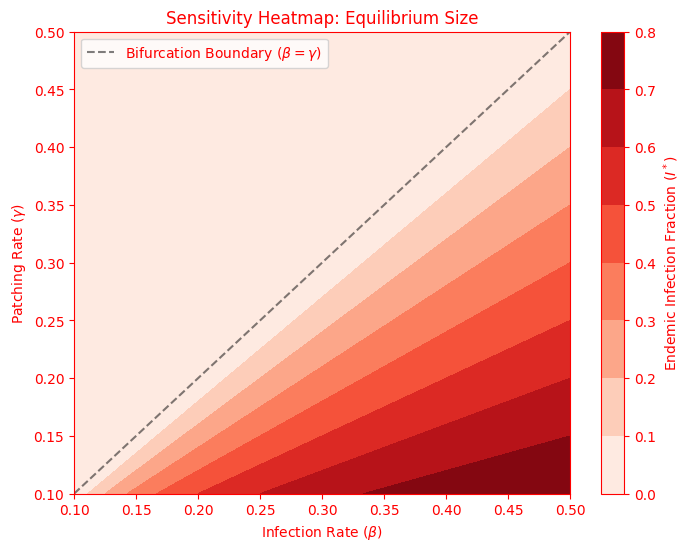

In [6]:
# --- VISUALIZATION 4: SENSITIVITY HEAT-MAP ---
fig4, ax = plt.subplots(figsize=(8, 6))

# Create grids for beta and gamma
beta_vals = np.linspace(0.1, 0.5, 100)
gamma_vals_hm = np.linspace(0.1, 0.5, 100)
B, G = np.meshgrid(beta_vals, gamma_vals_hm)

# Calculate equilibrium size
I_eq = np.maximum(0, 1 - G/B)

# Generate contour plot
c = ax.contourf(B, G, I_eq, cmap='Reds')
fig4.colorbar(c, ax=ax, label='Endemic Infection Fraction ($I^*$)')

ax.plot([0.1, 0.5], [0.1, 0.5], 'k--', alpha=0.5, label=r'Bifurcation Boundary ($\beta = \gamma$)')
ax.set_xlabel('Infection Rate ($\\beta$)')
ax.set_ylabel(r'Patching Rate ($\gamma$)')
ax.set_title('Sensitivity Heatmap: Equilibrium Size')
ax.legend()
plt.show()

## Visualization 5: SIR vs. SIRS Comparison
Overlaying the base model against the modified model to prove how patch expiration ($\mu$) creates a permanent endemic equilibrium.

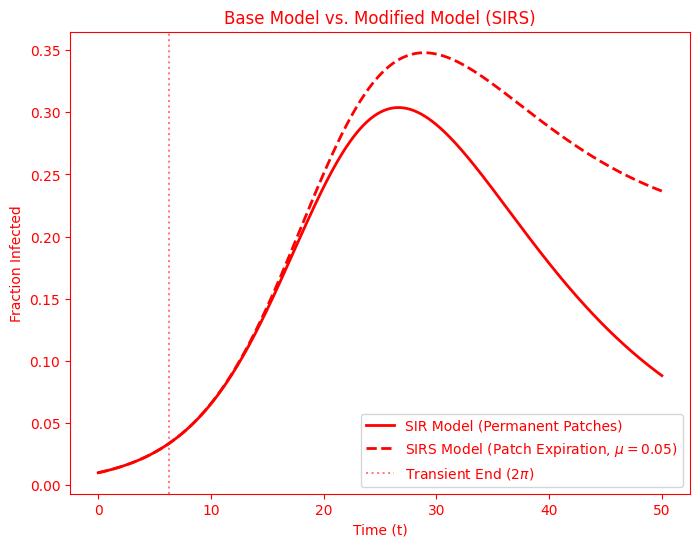

In [7]:
# --- VISUALIZATION 5: SIR VS SIRS COMPARISON ---
fig5, ax = plt.subplots(figsize=(8, 6))

# Base model: Gamma = 0.1, Beta = 0.3
sol_sir = odeint(sir_model, y0, t, args=(0.3, 0.1))

# Modified model: Adding patch expiration mu = 0.05
sol_sirs = odeint(sirs_model, y0, t, args=(0.3, 0.1, 0.05))

ax.plot(t, sol_sir[:, 1], 'r-', linewidth=2, label='SIR Model (Permanent Patches)')
ax.plot(t, sol_sirs[:, 1], 'r--', linewidth=2, label=r'SIRS Model (Patch Expiration, $\mu=0.05$)')

# Mark the transient state
ax.axvline(2*np.pi, color='red', linestyle=':', alpha=0.5, label=r'Transient End ($2\pi$)')

ax.set_xlabel('Time (t)')
ax.set_ylabel('Fraction Infected')
ax.set_title('Base Model vs. Modified Model (SIRS)')
ax.legend()
plt.show()